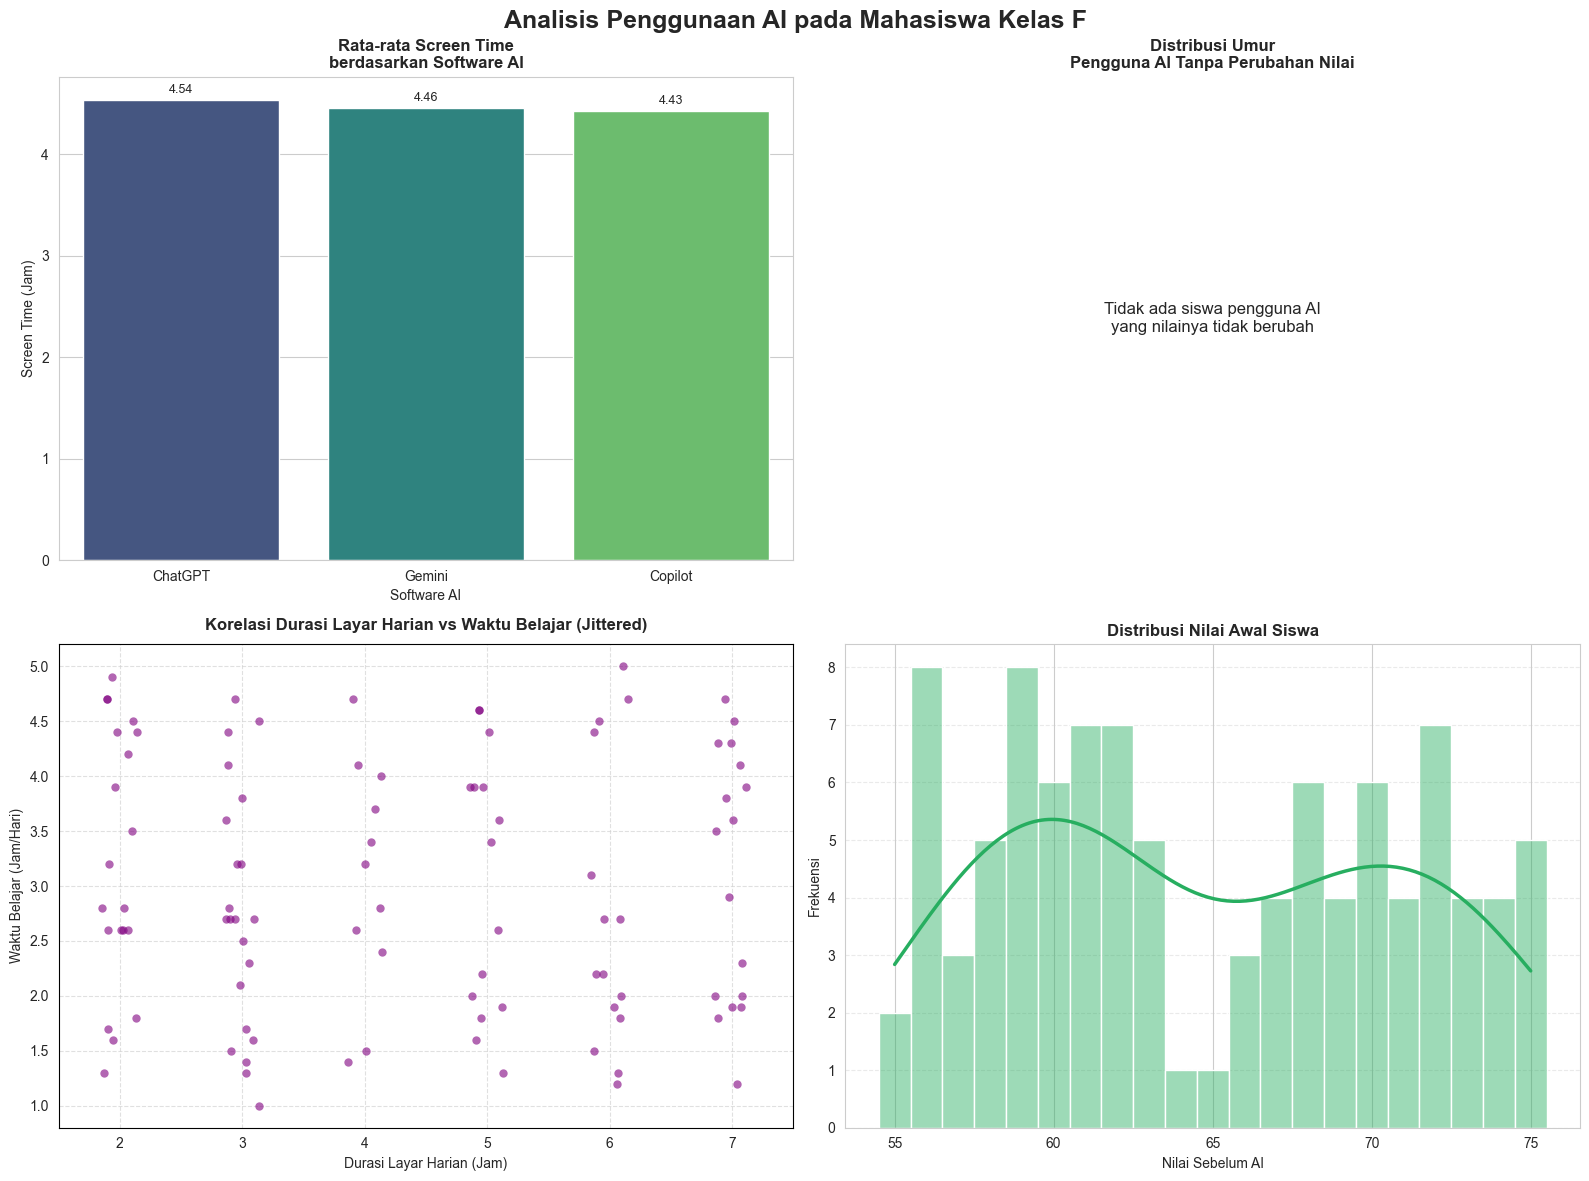

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 1. Load Dataset
df = pd.read_csv("Kelas F_Student AI Usage.csv")
sns.set_style("whitegrid")

# Pastikan folder assets ada di komputer agar tidak error saat save
if not os.path.exists("assets"):
    os.makedirs("assets")

# Fungsi pendukung Grafik C
def plot_kategori_c(ax):
    np.random.seed(42)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(0.8)
        spine.set_visible(True)

    sns.stripplot(
        x="daily_screen_time_hours",
        y="study_hours_per_day",
        data=df,
        color="purple",
        alpha=0.6,
        jitter=0.15,
        size=6,
        ax=ax,
    )
    ax.grid(True, which="both", linestyle="--", color="#D3D3D3", alpha=0.7)
    ax.set_axisbelow(True)
    ax.set_title("Korelasi Durasi Layar Harian vs Waktu Belajar (Jittered)", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Durasi Layar Harian (Jam)", fontsize=10)
    ax.set_ylabel("Waktu Belajar (Jam/Hari)", fontsize=10)

# 2. Inisialisasi Canvas Grid Layout 2 x 2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- SUBPLOT 1 (Kiri Atas) ---
data1 = df.groupby("ai_tools_used")["daily_screen_time_hours"].mean().sort_values(ascending=False).reset_index()
ax1 = axes[0, 0]
# Ditambahkan hue dan legend=False agar tidak memunculkan Future Warning seperti grafik A-mu
sns.barplot(x="ai_tools_used", y="daily_screen_time_hours", data=data1, palette="viridis", hue="ai_tools_used", legend=False, ax=ax1)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", xytext=(0, 5), textcoords="offset points", fontsize=9)
ax1.set_title("Rata-rata Screen Time\nberdasarkan Software AI", fontsize=12, fontweight="bold")
ax1.set_xlabel("Software AI", fontsize=10)
ax1.set_ylabel("Screen Time (Jam)", fontsize=10)

# --- SUBPLOT 2 (Kanan Atas) ---
filtered_df = df[(df["uses_ai"] == "Yes") & (df["grades_before_ai"] == df["grades_after_ai"])]
data2 = filtered_df["age"].value_counts().sort_index().reset_index()
data2.columns = ["age", "jumlah_siswa"]
ax2 = axes[0, 1]

if data2.empty:
    ax2.text(0.5, 0.5, "Tidak ada siswa pengguna AI\nyang nilainya tidak berubah", ha="center", va="center", fontsize=12)
    ax2.set_axis_off()
else:
    colors = ["#AEC6CF", "#FFB7B2", "#B5EAD7", "#E2F0CB", "#C7CEEA", "#FDFD96", "#FFDAB9", "#E6E6FA"]
    bar_colors = [colors[i % len(colors)] for i in range(len(data2))]
    bars = ax2.bar(data2["age"], data2["jumlah_siswa"], color=bar_colors, edgecolor="gray")
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, yval + 0.05, int(yval), ha="center", fontsize=9)
    ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.set_title("Distribusi Umur\nPengguna AI Tanpa Perubahan Nilai", fontsize=12, fontweight="bold")
ax2.set_xlabel("Umur", fontsize=10)
ax2.set_ylabel("Jumlah Siswa", fontsize=10)

# --- SUBPLOT 3 (Kiri Bawah) ---
plot_kategori_c(axes[1, 0])

# --- SUBPLOT 4 (Kanan Bawah) ---
ax4 = axes[1, 1]
sns.histplot(df["grades_before_ai"], kde=True, color="#27AE60", discrete=True, alpha=0.45, kde_kws={"bw_adjust": 1.2}, line_kws={"linewidth": 2.5}, edgecolor="white", ax=ax4)
ax4.set_title("Distribusi Nilai Awal Siswa", fontsize=12, fontweight="bold")
ax4.set_xlabel("Nilai Sebelum AI", fontsize=10)
ax4.set_ylabel("Frekuensi", fontsize=10)
ax4.grid(axis="y", linestyle="--", alpha=0.4)

# --- SUPER TITLE & LAYOUT ---
fig.suptitle("Analisis Penggunaan AI pada Mahasiswa Kelas F", fontsize=18, fontweight="bold", y=0.98)
plt.tight_layout()

# --- LANGKAH PENTING: OTOMATIS SAVE SEBELUM SHOW ---
plt.savefig("assets/grafik-5-gabungan.png", dpi=300, bbox_inches="tight")
plt.show()